In [1]:
import importlib
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import multiple_linear_regression
importlib.reload(multiple_linear_regression)
from multiple_linear_regression import compute_cost, compute_gradient, gradient_descent

In [27]:
data = pd.read_csv('data/clean_engineered_air_quality.csv')
print(data.columns)
data.head()

Index(['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'NO2(GT)', 'PT08.S3(NOx)_sq', 'T_sq',
       'AH_log', 'T_RH', 'PT08.S3(NOx)_log'],
      dtype='object')


,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,NO2(GT),PT08.S3(NOx)_sq,T_sq,AH_log,T_RH,PT08.S3(NOx)_log
0,1360.00,1045.50,1056.25,1692.00,1267.50,13.60,48.875001,0.757754,113.0,1.115664e+06,184.959997,-0.277384,664.700008,6.963426
1,1292.25,954.75,1173.75,1558.75,972.25,13.30,47.700000,0.725487,92.0,1.377689e+06,176.889999,-0.320898,634.409995,7.068811
2,1402.00,939.25,1140.00,1554.50,1074.00,11.90,53.975000,0.750239,114.0,1.299600e+06,141.610002,-0.287350,642.302510,7.039660
3,1375.50,948.25,1092.00,1583.75,1203.25,11.00,60.000000,0.786713,122.0,1.192464e+06,121.000000,-0.239880,660.000000,6.996681
4,1272.25,835.50,1205.00,1490.00,1110.00,11.15,59.575001,0.788794,116.0,1.452025e+06,124.322502,-0.237237,664.261264,7.095064


In [28]:
X = data[['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)',
          'PT08.S5(O3)', 'T', 'RH', 'AH', 'PT08.S3(NOx)_sq',
          'PT08.S3(NOx)_log', 'T_sq', 'AH_log', 'T_RH']]
y = data['NO2(GT)']

In [29]:
# z-score normalize
def z_score_normalize(X_train):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    X_norm = (X_train - mean) / std
    return X_norm

In [30]:
#normalize features
X_norm = z_score_normalize(X)
print("Normalized Features:\n")
X_norm.head()

Normalized Features:



,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,PT08.S3(NOx)_sq,PT08.S3(NOx)_log,T_sq,AH_log,T_RH
0,1.178180,0.386336,0.874538,0.695918,0.581269,-0.527421,-0.018272,-0.651117,0.697619,0.948109,-0.628037,-0.465647,-0.425762
1,0.867671,0.047528,1.334069,0.307641,-0.148787,-0.561582,-0.086613,-0.731345,1.209641,1.302373,-0.650607,-0.563373,-0.514471
2,1.370673,-0.010340,1.202076,0.295257,0.102808,-0.721001,0.278357,-0.669802,1.057048,1.204380,-0.749277,-0.488030,-0.491357
3,1.249219,0.023261,1.014353,0.380488,0.422400,-0.823484,0.628787,-0.579113,0.847694,1.059900,-0.806918,-0.381419,-0.439527
4,0.776008,-0.397683,1.456285,0.107310,0.191824,-0.806404,0.604068,-0.573937,1.354901,1.390628,-0.797626,-0.375484,-0.427047


In [31]:
# Initialize parameters
init_w = np.zeros(X.shape[1])
init_b = 0

iterations = 10000
alpha = 0.001

In [32]:
w_final, b_final, J_hist = gradient_descent(X_norm, y, init_w, init_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

In [33]:
print("w_final:", w_final)
print("b_final:", b_final)
print("final cost:", J_hist[-1])

w_final: PT08.S1(CO)          6.697302
PT08.S2(NMHC)        7.605047
PT08.S3(NOx)        -6.378458
PT08.S4(NO2)       -10.166851
PT08.S5(O3)         12.268910
T                   -1.041453
RH                  -1.391310
AH                  -3.128007
PT08.S3(NOx)_sq     -1.336922
PT08.S3(NOx)_log    -9.006026
T_sq                 3.755565
AH_log              -5.256780
T_RH                -8.175327
dtype: float64
b_final: 109.61508122659414
final cost: 344.0839886049314


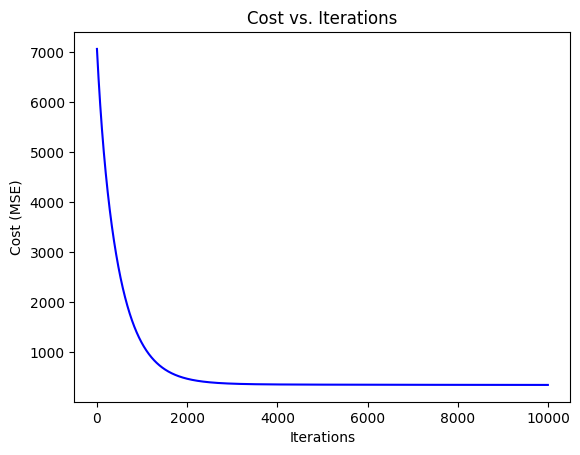

In [34]:
plt.plot(range(iterations), J_hist, color='blue')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Cost vs. Iterations')
plt.show()

In [35]:
# Prediction function
def predict(X, w, b):
    return X @ w + b  # (m,)

In [36]:
# Evaluation Metrics

# sse - sum of squared errors
def sse(y, yhat):
    r = yhat - y
    return float(np.sum(r * r))

# sst - total sum of squares
def sst(y):
    ybar = float(np.mean(y))
    return float(np.sum((y - ybar) ** 2))

# mse - mean squared error
def mse(y, yhat):
    m = len(y)
    return sse(y, yhat) / m

# rmse - root mean squared error
def rmse(y, yhat):
    return np.sqrt(mse(y, yhat))

# r2 - coefficient of determination
def r2(y, yhat):
    denom = sst(y)
    return 1.0 - sse(y, yhat) / denom if denom != 0.0 else np.nan

# mae - mean absolute error
def mae(y, yhat):
    return float(np.mean(np.abs(yhat - y)))

# adjusted r2 - adjusted coefficient of determination
def adj_r2(y, yhat, p):
    # p = number of features (len(w))
    m = len(y)
    r2_val = r2(y, yhat)
    return 1.0 - (1.0 - r2_val) * (m - 1) / (m - p - 1) if (m - p - 1) > 0 else np.nan

In [37]:
yhat_train = predict(X_norm, w_final, b_final)
print(f"R²:   {r2(y, yhat_train):.3f}")
print(f"RMSE: {rmse(y, yhat_train):.2f}")
print(f"MAE:  {mae(y, yhat_train):.2f}")
print(f"AdjR²:{adj_r2(y, yhat_train, p=len(w_final)):.3f}")

R²:   0.681
RMSE: 26.23
MAE:  19.63
AdjR²:0.681


In [38]:
# calculate residuals
y_pred = predict(X_norm, w_final, b_final)
residuals = y - y_pred

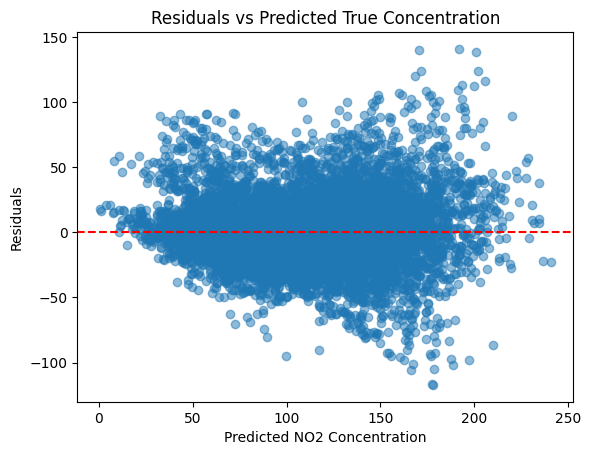

In [39]:

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted NO2 Concentration")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted True Concentration")
plt.show()

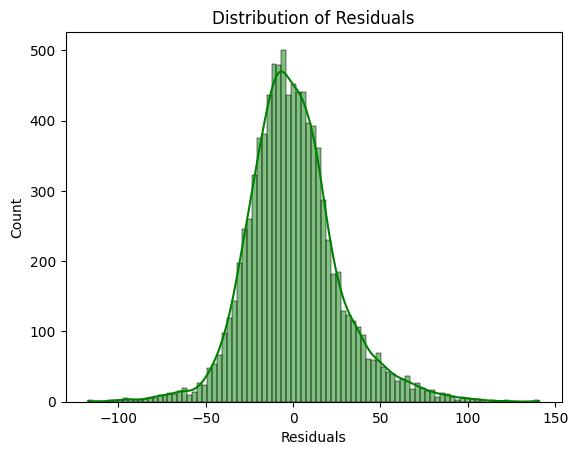

In [40]:
# Histogram of residuals for normality check
sns.histplot(residuals, kde=True, color='green')
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
plt.show()

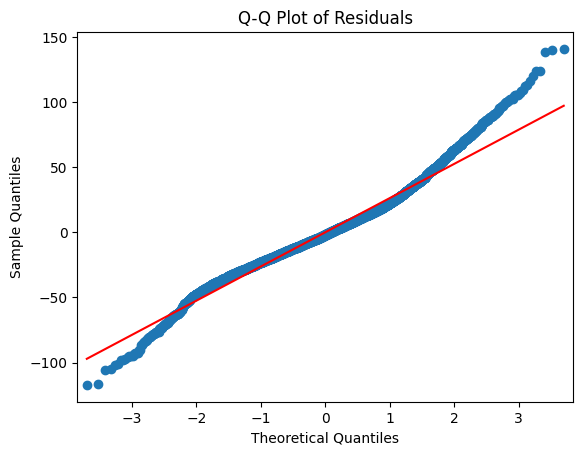

In [41]:
# Q-Q plot for residuals
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

### SKlearn Comparison

In [2]:
data2 = pd.read_csv('data/clean_air_quality.csv')
print(data2.columns)
data2.head()

Index(['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'NO2(GT)'],
      dtype='object')


,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,NO2(GT)
0,1360.00,1045.50,1056.25,1692.00,1267.50,13.60,48.875001,0.757754,113.0
1,1292.25,954.75,1173.75,1558.75,972.25,13.30,47.700000,0.725487,92.0
2,1402.00,939.25,1140.00,1554.50,1074.00,11.90,53.975000,0.750239,114.0
3,1375.50,948.25,1092.00,1583.75,1203.25,11.00,60.000000,0.786713,122.0
4,1272.25,835.50,1205.00,1490.00,1110.00,11.15,59.575001,0.788794,116.0


In [43]:
X2 = data2[['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)',
           'PT08.S5(O3)', 'T', 'RH', 'AH']]

y2 = data2['NO2(GT)']

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

# split data
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.20, random_state=42)

# model
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', Ridge(alpha=1.0))
])

# fit and predict
poly_model.fit(X_train, y_train)
y_hat = poly_model.predict(X_test)

# evaluation
r2   = r2_score(y_test, y_hat)
rmse = root_mean_squared_error(y_test, y_hat)
mae  = mean_absolute_error(y_test, y_hat)

# Adjusted R² (p = number of predictors after PolynomialFeatures; exclude intercept)
p = poly_model.named_steps['poly'].n_output_features_
n = y_test.shape[0]
adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / (n - p - 1) if (n - p - 1) > 0 else np.nan

print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"AdjR²:{adj_r2:.3f}")

R²:   0.747
RMSE: 22.98
MAE:  17.06
AdjR²:0.741


In [45]:
feature_names = poly_model.named_steps['poly'].get_feature_names_out(input_features=X2.columns)
print(feature_names)

['PT08.S1(CO)' 'PT08.S2(NMHC)' 'PT08.S3(NOx)' 'PT08.S4(NO2)' 'PT08.S5(O3)'
 'T' 'RH' 'AH' 'PT08.S1(CO)^2' 'PT08.S1(CO) PT08.S2(NMHC)'
 'PT08.S1(CO) PT08.S3(NOx)' 'PT08.S1(CO) PT08.S4(NO2)'
 'PT08.S1(CO) PT08.S5(O3)' 'PT08.S1(CO) T' 'PT08.S1(CO) RH'
 'PT08.S1(CO) AH' 'PT08.S2(NMHC)^2' 'PT08.S2(NMHC) PT08.S3(NOx)'
 'PT08.S2(NMHC) PT08.S4(NO2)' 'PT08.S2(NMHC) PT08.S5(O3)'
 'PT08.S2(NMHC) T' 'PT08.S2(NMHC) RH' 'PT08.S2(NMHC) AH' 'PT08.S3(NOx)^2'
 'PT08.S3(NOx) PT08.S4(NO2)' 'PT08.S3(NOx) PT08.S5(O3)' 'PT08.S3(NOx) T'
 'PT08.S3(NOx) RH' 'PT08.S3(NOx) AH' 'PT08.S4(NO2)^2'
 'PT08.S4(NO2) PT08.S5(O3)' 'PT08.S4(NO2) T' 'PT08.S4(NO2) RH'
 'PT08.S4(NO2) AH' 'PT08.S5(O3)^2' 'PT08.S5(O3) T' 'PT08.S5(O3) RH'
 'PT08.S5(O3) AH' 'T^2' 'T RH' 'T AH' 'RH^2' 'RH AH' 'AH^2']


In [46]:
coefs = poly_model.named_steps['reg'].coef_
print(coefs)

[ 34.72802417  25.24046246 -71.15537458 -48.39756035 -10.45430091
 -23.79511891 -10.82974036 -38.75697075   8.57923389  -6.42396502
 -15.88442395 -43.66730999  20.67746518 -16.30348112  27.7828496
  -2.61256745 -58.66859905   2.67838394  58.46218188  42.36094091
  15.11973432   4.43161602 -15.46358676  30.91064313  22.25508217
   7.80732126   1.17079654  -2.92469188  29.17898255 -37.5059392
  18.37330393  43.76140555  13.46830265  31.43660899 -15.5255783
 -15.52507707 -53.35987005  15.63499538  -6.09131427 -16.1668821
  22.76949793  -1.14104822  16.35410215 -25.35751612]
